<a href="https://colab.research.google.com/github/wajdalkhaldi/NLP/blob/main/lab3/Lab3_N_Grams_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

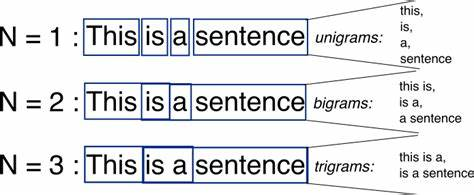

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** is an n-gram consisting of a single item of a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$$
P(A) = \frac{\text{count of } A}{\text{count of all words}}
$$

In [2]:
#n grams measure the goodness using probabilities estimated and it
#n grams learns by: 1- coun how often word consequences appear in corpus 2- turn counts to probabilities
# use cases of n grams : 1- auto spell check , 2- voice based assistant based , 3-
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1) # 1 indicate that division of groups into single words

for item in unigrams:
    print(item)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Calculating probabilities in unigram models

In [3]:
### Calculate counts of each word (unique words)

unique_string = set(word_tokenize(string)) #set function print each unique word to be counted once

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques) #count frequincy
    words_frq.append((uniques, frq))

words_frq

[('toeses', 1),
 ('are', 1),
 ('his', 1),
 ('supposes', 2),
 ('roses', 1),
 ('moses', 2),
 ('erroneously', 1),
 ('but', 1)]

In [4]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)): #len to trace the whole sentence
    pro = words_frq[count][1]/len(word_tokenize(string)) #to calculate probabilty of uni grams
    probab.append((words_frq[count][0],pro))

print('The probabilities are: ', probab)

The probabilities are:  [('toeses', 0.1), ('are', 0.1), ('his', 0.1), ('supposes', 0.2), ('roses', 0.1), ('moses', 0.2), ('erroneously', 0.1), ('but', 0.1)]


## Bigram

**Bigram** an n-gram consisting of two items of a sequence
- Two words that are used together to mean something specific

$$
P(B \mid A) = \frac{\text{Count of }(AB)}{\text{Count of }(A)}
$$

### Method 1

In [5]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nltk.bigrams(word_tokenize(string)) #function of bigrams
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2) #n grams used ti divide into groups of defined words

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [6]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nltk.trigrams(word_tokenize(string)) #function for trigrams

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

Padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

**n-1 padding is added.**



In [ ]:
#paddding is a technique used to ensure hat all input sequences have same length by adding special tags

from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

print('------------------- Padding in Bigrams ------------------------------')
list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>", #ngrams always start with tokenization
                                pad_right=True, right_pad_symbol="</s>", n=2))

------------------- Padding in Bigrams ------------------------------


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

In [ ]:
print('------------------- Padding in Trigrams ------------------------------')
list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=3))

------------------- Padding in Trigrams ------------------------------


[('<s>', '<s>', 'moses'),
 ('<s>', 'moses', 'supposes'),
 ('moses', 'supposes', 'his'),
 ('supposes', 'his', 'toeses'),
 ('his', 'toeses', 'are'),
 ('toeses', 'are', 'roses'),
 ('are', 'roses', 'but'),
 ('roses', 'but', 'moses'),
 ('but', 'moses', 'supposes'),
 ('moses', 'supposes', 'erroneously'),
 ('supposes', 'erroneously', '</s>'),
 ('erroneously', '</s>', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [ ]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2)) #function that does padding in both ends directly --> the indie n=2: 2 special tags, outer n=2:for bigrams


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.


- Build the vocabulary (of unique words): to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create an Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.

The  padded_everygram_pipeline() will return:  
1- **ngrams_gen:** Each sentence becomes a list of n-grams with padding.  
2- **vocab_gen:** A flat stream of all tokens, with start and end symbols included  

**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [7]:
#max liklihood estimation by n grams

from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [8]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model

### Calculating Probabilities
Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [ ]:
print(lm.score('supposes', ['moses'])) #Calculate Bigram Probabilities for P('moses'|'supposes')
print(lm.score('moses', ['supposes'])) #Calculate Bigram Probabilities for P('supposes'|'moses') - Returns 0 because unseen
# you should know how yo measure manually for the quiz

1.0
0.0


### Evaluating n_grams models using preplexity

**Preplexity** is a measurement of how well a probability model (like a language model) predicts a sample.

It's the probability of the test set normalized by the number of words.

A `lower` perplexity means:

- The model is less “perplexed” by the data.

- The model assigns higher probabilities to the actual words in the test set.

- Therefore, better performance.

A `higher perplexity` = more uncertainty = worse model.

In [ ]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test)) #Perplexity for bigram model

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions
*   Remove emojis


3. build MLE model with n-gram (Bi-gram)
4. evaluate the model
5. calculate the probability of the bigram: (pakistan is)
6. calculate the preplexity of the word: (pakistan)

before we start we need to install library to handle the emojis in tweets
> pip install emoji

In [16]:
# Install emoji library
!pip install emoji -q


#import libraries
import os
import re
import math
import glob
import pandas as pd
import numpy as np
import emoji

from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline

import nltk

# Download tokenizer resources
nltk.download('punkt')
nltk.download('punkt_tab')


# Load the dataset

csv_files = glob.glob('/content/*.csv')

if len(csv_files) == 0:
    print("Please upload the Kaggle CSV dataset to Colab, then run this cell again.")
    raise FileNotFoundError("No CSV file found.")
else:
    print("CSV files found:")
    for f in csv_files:
        print(f)

    # Try different encodings because some Kaggle CSV files are not UTF-8
    encodings = ['utf-8', 'cp1252', 'latin1']

    df = None

    for encoding in encodings:
        try:
            print(f"\nTrying encoding: {encoding}")

            df = pd.read_csv(
                csv_files[0],
                encoding=encoding
            )

            print(f"Successfully loaded using {encoding}")
            break

        except UnicodeDecodeError:
            print(f"Could not load using {encoding}")

    # Check if the CSV could not be loaded
    if df is None:
        raise ValueError(
            "Could not read the CSV file using utf-8, cp1252, or latin1."
        )

    print("\nDataset shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())


#finding the tweet column


#look for a column containing tweet/text data
possible_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in
           ['tweet', 'text', 'content', 'status'])
]

if len(possible_columns) > 0:
    text_column = possible_columns[0]
else:
    string_columns = df.select_dtypes(include=['object']).columns.tolist()

    if len(string_columns) == 0:
        raise ValueError("No text column was found in the dataset.")

    text_column = string_columns[0]

print("\nText column selected:", text_column)


#preprocessing function

def preprocess_tweet(text):

    text = str(text) # Convert to string

    text = re.sub(r'\bRT\b', '', text, flags=re.IGNORECASE)  #Remove RT

    text = re.sub(r'https?://\S+|www\.\S+', '', text)  #Remove URLs or websites

    text = re.sub(r'#\w+', '', text) #remove hashtags

    text = re.sub(r'@\w+', '', text) #remove mentions

    text = emoji.replace_emoji(text, replace='') # Remove emojis

    text = text.lower() # Convert to lowercase

    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces

    return text


df['clean_tweet'] = df[text_column].apply(preprocess_tweet) # apply preprocessing

df = df[df['clean_tweet'].str.strip() != ''] # remove empty tweets

print("\nNumber of tweets after preprocessing:", len(df))

print("\nExample of original tweet:")
print(df[text_column].iloc[0])

print("\nExample of cleaned tweet:")
print(df['clean_tweet'].iloc[0])


# Tokenize tweets

tokenized_tweets = []

for tweet in df['clean_tweet']:
    tokens = word_tokenize(tweet)

    if len(tokens) > 0:
        tokenized_tweets.append(tokens)

print("\nNumber of tokenized tweets:", len(tokenized_tweets))

print("\nExample tokens:")
print(tokenized_tweets[0])



# Split data into training and testing sets


train_data, test_data = train_test_split(
    tokenized_tweets,
    test_size=0.2,
    random_state=42
)

print("\nTraining tweets:", len(train_data))
print("Testing tweets:", len(test_data))



# Buildong Bigram Model


N = 2


train_ngrams, vocabulary = padded_everygram_pipeline( # Prepare training data for the MLE model
    N,
    train_data
)

model = MLE(N) # Create model

model.fit(train_ngrams, vocabulary) # Train the model

print("\nBigram MLE model trained successfully.")

print("Vocabulary size:", len(model.vocab))

#Evaluate the model

test_ngrams, _ = padded_everygram_pipeline( #Calculate perplexity on test data
    N,
    test_data
)

test_ngrams = list(test_ngrams)


perplexities = []

for sentence in test_ngrams:
    bigrams_sentence = list(sentence) # Keep only bigrams

    try:
        pp = model.perplexity(bigrams_sentence)

        if math.isfinite(pp):
            perplexities.append(pp)

    except:
        pass


if len(perplexities) > 0:

    average_perplexity = np.mean(perplexities)

    print("\nModel Evaluation")
    print("---------------------------")
    print("Average test perplexity:",
          average_perplexity)

else:
    print("\nCould not calculate test perplexity.")



# Calculate probability of the bigram: (pakistan is)


word1 = "pakistan"
word2 = "is"

probability = model.score(word2, [word1])

print("\nProbability of the bigram (pakistan is):")
print(probability)



# Calculate perplexity of the word: (pakistan)


# Perplexity of a unigram can be calculated from the probability of the word.
pakistan_count = model.counts[1]["pakistan"]
print("Count of 'pakistan':", pakistan_count)


if pakistan_count > 0:
    pakistan_perplexity = 1 / pakistan_count

    print("\nProbability of 'pakistan':")
    print(pakistan_count)

    print("\nPerplexity of the word (pakistan):")
    print(pakistan_count)

else:
    print("\nThe word 'pakistan' was not found in the vocabulary.")



# Generate tweets using the trained bigram model


def generate_tweet(num_words=15):

    generated = ["<s>"]

    for i in range(num_words):

        context = generated[-1]

        # Get possible next words
        candidates = []

        for word in model.vocab:
            probability = model.score(word, [context])

            if probability > 0:
                candidates.append((word, probability))

        if len(candidates) == 0:
            break

        # Choose the most probable next word
        next_word = max(
            candidates,
            key=lambda x: x[1]
        )[0]

        if next_word == "</s>":
            break

        generated.append(next_word)

    return " ".join(generated[1:])


print("\nGenerated Tweets")
print("---------------------------")

for i in range(5):
    print(generate_tweet(15))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


CSV files found:
/content/Random Tweets from Pakistan- Cleaned- Anonymous-1.csv

Trying encoding: utf-8
Could not load using utf-8

Trying encoding: cp1252
Could not load using cp1252

Trying encoding: latin1
Successfully loaded using latin1

Dataset shape: (202202, 7)

Columns:
['Unnamed: 0', 'created_at_tweet', 'full_text', 'retweet_count', 'favorite_count', 'reply_count', 'location']

First 5 rows:


/tmp/ipykernel_1712/3063993471.py:48: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,Unnamed: 0,created_at_tweet,full_text,retweet_count,favorite_count,reply_count,location
0,0,Wed Jul 03 07:20:15 +0000 2019,ØªÛØ±Ø§ ÙÛÚØ± Ù ÛØ±Ø§ ÙÛÚØ± ÙÙØ§Ø² Ø...,226,1097,127,"Punjab, Pakistan"
1,1,Fri Jul 02 02:50:53 +0000 2021,"Happy birthday to my brother n boss , May you ...",54,273,9,"Punjab, Pakistan"
2,2,Fri Jul 02 12:12:53 +0000 2021,â¤ï¸â¤ï¸,50,131,13,"Punjab, Pakistan"
3,3,Tue Oct 15 22:29:16 +0000 2019,`suspicious Â°jikook au jimin'in yaÅadÄ±ÄÄ± ...,522,2134,86,"Ä°stanbul, TÃ¼rkiye"
4,4,Wed May 13 04:34:31 +0000 2020,Speaking of @SpiderMan... ð https://t.co/...,74,535,11,Follow the ATP Tour â¡



Text column selected: created_at_tweet

Number of tweets after preprocessing: 202202

Example of original tweet:
Wed Jul 03 07:20:15 +0000 2019

Example of cleaned tweet:
wed jul 03 07:20:15 +0000 2019

Number of tokenized tweets: 202202

Example tokens:
['wed', 'jul', '03', '07:20:15', '+0000', '2019']

Training tweets: 161761
Testing tweets: 40441

Bigram MLE model trained successfully.
Vocabulary size: 70110

Model Evaluation
---------------------------
Average test perplexity: 55.38145985153021

Probability of the bigram (pakistan is):
0.0
Count of 'pakistan': 7938

Probability of 'pakistan':
7938

Perplexity of the word (pakistan):
7938

Generated Tweets
---------------------------
sun jul 04 15:01:00 +0000 2021
sun jul 04 15:01:00 +0000 2021
sun jul 04 15:01:00 +0000 2021
sun jul 04 15:01:00 +0000 2021
sun jul 04 15:01:00 +0000 2021
